In [2]:
import numpy as np
import pandas as pd
from itertools import combinations
import torch
import matplotlib.pyplot as plt

AAs = 'ACDEFGHIKLMNPQRSTVWY-'
AAs_dict = {i : AAs[i] for i in range(21)}

In [2]:
data = pd.read_csv('../../data/Byrne.csv',index_col=0).query('T0 > 0').sort_values('T0', ascending=False).iloc[1:]
data

,a1,a2,a3,a4,a5,a6,a7,T0,T0PV,T1,T2,T3,T4,T5,subset
combine_name,,,,,,,,,,,,,,,
KSDQSKP,8,15,2,13,15,8,12,303,1994,7438,3604,7578,554845,755459,1
KQAPEKS,8,13,0,12,3,8,15,258,824381,131779,257481,158421,76684,28784,0
SSPTTKS,15,15,12,16,16,8,15,250,1109253,222026,135376,75250,10013,2514,3
TTPIAKP,16,16,12,7,0,8,12,212,17015,10101,10170,26506,326860,259367,2
GAKAQVP,5,0,8,0,13,17,12,205,789474,152630,284163,225023,47605,16762,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LGTCTQQ,9,5,16,1,16,13,13,1,0,0,0,0,0,0,3
RSPSSPW,14,15,12,15,15,12,18,1,0,0,0,0,0,0,2
GWVLACG,5,18,17,9,0,1,5,1,0,0,0,0,0,0,3


In [3]:
counts = data['T0'].to_numpy()
data = data.iloc[:,:7].to_numpy()

In [30]:
file = open('ByrneT0_input','w')

R = counts.sum()

for i in combinations(np.arange(7), 2):
    for a1 in range(20):
        for a2 in range(20):
            a = counts[(data[:,i[0]]==a1)&(data[:,i[1]]==a2)].sum() / R
            file.write('s %d %d %s %s %.4e\n'%(i[0], i[1], AAs[a1], AAs[a2], a))
    print(i)

for i in range(7):
    for a in range(20):
        a_ = counts[data[:,i]==a].sum() / R
        file.write('m %d %s %.4e\n'%(i, AAs[a], a_))
    print(i)
file.close()

(0, 1)
(0, 2)
(0, 3)
(0, 4)
(0, 5)
(0, 6)
(1, 2)
(1, 3)
(1, 4)
(1, 5)
(1, 6)
(2, 3)
(2, 4)
(2, 5)
(2, 6)
(3, 4)
(3, 5)
(3, 6)
(4, 5)
(4, 6)
(5, 6)
0
1
2
3
4
5
6


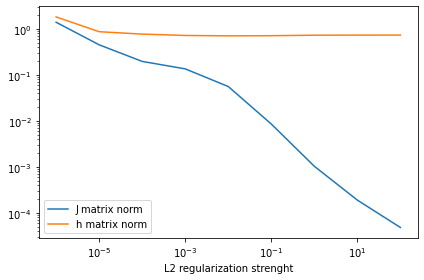

In [14]:
N = 9
l2_vector = np.logspace(-6,2,N)
norm_couplings = np.zeros(N)
norm_fields = np.zeros(N)
for i in range(N):
    norm_couplings[i] = np.sqrt((np.load("ByrneT0_couplings_%.2e.npy"%l2_vector[i])**2).sum() / (2*21*20*20))
    norm_fields[i] = np.sqrt((np.load("ByrneT0_fields_%.2e.npy"%l2_vector[i])**2).sum() / (7*20))

plt.figure(facecolor='white')
plt.plot(l2_vector, norm_couplings, label='J matrix norm')
plt.plot(l2_vector, norm_fields, label='h matrix norm')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('L2 regularization strenght')
plt.legend()
plt.tight_layout()
plt.savefig('ByrneT0_norm_vs_regularization.png')